In [1]:
import pandas as pd
df=pd.read_csv("data/AEP_hourly.csv")
print(df.head())


              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


In [2]:
print(df.shape)
print(df.columns)
print(df.info())


(121273, 2)
Index(['Datetime', 'AEP_MW'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB
None


In [6]:
df['Datetime']=pd.to_datetime(df['Datetime'])

In [9]:
df['hour']=df['Datetime'].dt.hour
df['day']=df['Datetime'].dt.day
df['month']=df['Datetime'].dt.month
df['year']=df['Datetime'].dt.year
df['weekday']=df['Datetime'].dt.weekday

In [10]:
print(df.head())


             Datetime   AEP_MW  hour  day  month  year  weekday
0 2004-12-31 01:00:00  13478.0     1   31     12  2004        4
1 2004-12-31 02:00:00  12865.0     2   31     12  2004        4
2 2004-12-31 03:00:00  12577.0     3   31     12  2004        4
3 2004-12-31 04:00:00  12517.0     4   31     12  2004        4
4 2004-12-31 05:00:00  12670.0     5   31     12  2004        4


In [11]:
X = df[['hour', 'day', 'month', 'year', 'weekday']]

y = df['AEP_MW']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)



,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
predictions = model.predict(X_test)


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 336.1532875695733
R2 Score: 0.9587015774223372


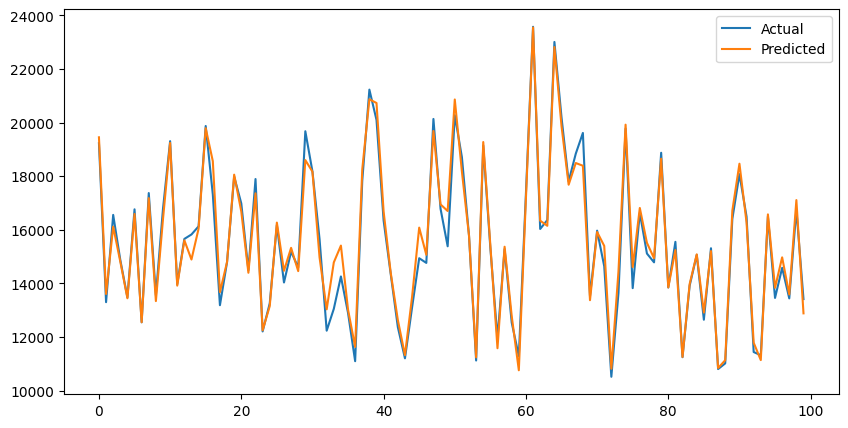

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.legend()
plt.show()

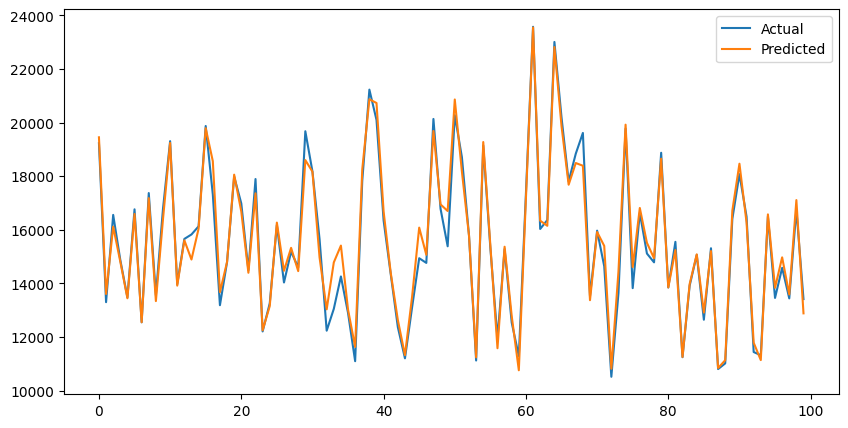

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.legend()

plt.savefig("prediction_graph.png")

plt.show()


In [18]:
plt.savefig("images/prediction_graph.png")


<Figure size 640x480 with 0 Axes>

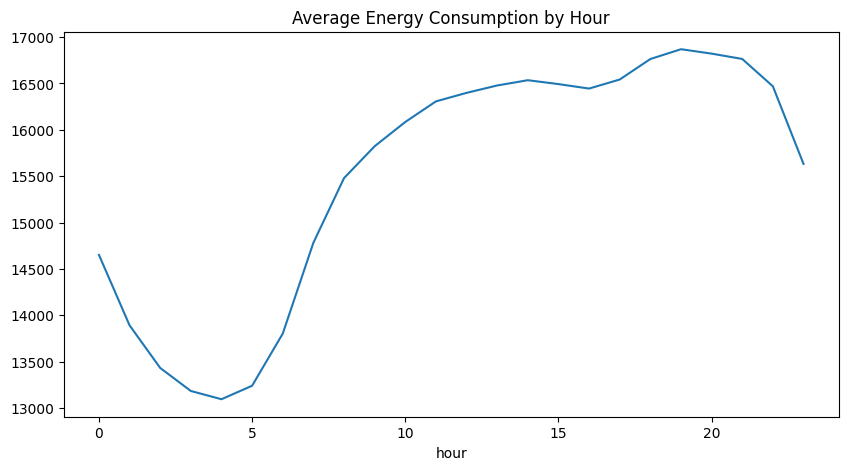

In [19]:
df.groupby('hour')['AEP_MW'].mean().plot(figsize=(10,5))
plt.title("Average Energy Consumption by Hour")
plt.show()


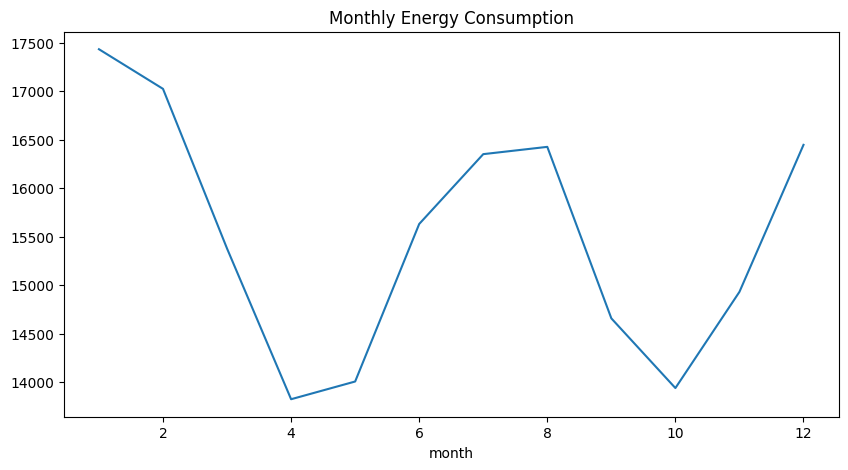

In [20]:
df.groupby('month')['AEP_MW'].mean().plot(figsize=(10,5))
plt.title("Monthly Energy Consumption")
plt.show()